In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from matplotlib.lines import Line2D

# ============================================================================
# CONSTANTS
# ============================================================================
sigma_B = 5.6696e-8  # W/(m^2 K^4)
sigma_B_scaled = 5.6696
solar_const = 1368  # W/m^2
r_earth = 6371e3  # m
area_earth = 4 * np.pi * r_earth**2  # m^2
emissivity_earth = 1
transmissivity_atm = 0.63
albedo_sky = 0.2
albedo_surface = 0.4
albedo_ocean = 0.1
albedo_ice = 0.6
density_land = 2500  # kg/m^3
density_water = 1028  # kg/m^3
density_ice = 900  # kg/m^3
depth_land = 1  # m
depth_ocean = 70  # m
depth_ice = 1  # m
spec_heat_land = 790  # J kg/K
spec_heat_water = 4187  # J kg/K
spec_heat_ice = 2060  # J kg/K

# Rotational constants
day_length = 24 * 3600  # s
earth_tilt = 23.5  # degree
year_length = 365 * day_length  # s
earth_rot_speed = 360 / day_length  # deg / s

In [3]:
# ============================================================================
# VOLCANIC FORCING PARAMETERS
# ============================================================================
lat_edges = np.arange(-90, 91, 30)   # -90 to 90 by 30
lon_edges = np.arange(-180, 181, 30) # -180 to 180 by 30

ERUPTIONS = [dict(
    t0_days=500.0, lat=48.7767, lon=-121.8144, amplitude=0.5,
    tau_rise_days=60.0, tau_decay_days=730.0,
    sigma_lat0_deg=15.0, sigma_latmax_deg=60.0,
    sigma_lon0_deg=30.0, sigma_lonmax_deg=180.0,
    tau_spread_days=150.0, hemi_bias=0.4
)]

def volcanic_phi_field(t_days):
    """
    Returns φ on the 12×6 grid at time t_days (in [0.15, 1]).
    """
    phi = np.ones((12, 6))
    LAT, LON = np.meshgrid(0.5*(lat_edges[:-1]+lat_edges[1:]),
                           0.5*(lon_edges[:-1]+lon_edges[1:]), indexing='ij')
    LAT = LAT.T
    LON = LON.T
    
    for e in ERUPTIONS:
        if t_days < e['t0_days']: 
            continue
        A = e['amplitude']
        lat0, lon0 = e['lat'], e['lon']
        dt = t_days - e['t0_days']
        amp = A * (1.0 - np.exp(-dt/e['tau_rise_days'])) * np.exp(-dt/e['tau_decay_days'])
        grow = 1.0 - np.exp(-dt/e['tau_spread_days'])
        sig_lat = np.deg2rad(e['sigma_lat0_deg'] + (e['sigma_latmax_deg']-e['sigma_lat0_deg'])*grow)
        sig_lon = np.deg2rad(e['sigma_lon0_deg'] + (e['sigma_lonmax_deg']-e['sigma_lon0_deg'])*grow)
        dlat = np.deg2rad(LAT - lat0)
        dlon = np.deg2rad((LON - lon0 + 180.0) % 360.0 - 180.0)
        w = np.exp(-0.5*(dlat/sig_lat)**2) * np.exp(-0.5*(dlon/sig_lon)**2)
        if w.max() > 0: 
            w /= w.max()
        # Amplify in the source hemisphere
        w *= np.where(np.sign(LAT)==np.sign(lat0), 1.0+e['hemi_bias'], 1.0)
        phi *= (1.0 - amp*w)
    
    return np.clip(phi, 0.15, 1.0)

# ============================================================================
# GRID AND ZONAL PROPERTIES
# ============================================================================
area_fractions = np.array(12*[[0.0670, 0.1830, 0.2500, 0.2500, 0.1830, 0.0670]]) / 12

grid = []
for j in range(len(lon_edges) - 1):      # 12 longitude bands
    for i in range(len(lat_edges) - 1):  # 6 latitude bands
        lat1, lat2 = lat_edges[i], lat_edges[i+1]
        lon1, lon2 = lon_edges[j], lon_edges[j+1]
        grid.append((lat1, lat2, lon1, lon2))
grid = np.array(grid).reshape(12, 6, 4)

# Zonal exchanges
lengths_lat = np.array(12*[[2.0015e7, 3.4667e7, 4.0030e7, 3.4667e7, 2.0015e7]]) / 12  # m
lengths_lon = np.array(12*[6*[np.pi * r_earth]]) / 6  # m
k_vals_lat = np.ones((12, 5)) * 1e7  # W / (m K)
k_vals_lon = np.ones((12, 6)) * 1e7  # W / (m K)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def compute_pcZ(p, c, z):
    return p * c * z

def compute_albedo(a):
    return a

def average_fcn(f, func, *args):
    """Takes in a list of length 3 for each of the input variables and returns 
    the weighted average based on the fraction f"""
    f = np.array(f)
    assert np.isclose(np.sum(f), 1.0, atol=1e-5), f"Fractions must sum to 1. Value was {np.sum(f)}. Fractions were {f}"
    assert np.min(f) >= 0, "Fractions cannot be negative"

    total = 0
    for i in range(len(f)):
        total += f[i] * func(*[arg[i] for arg in args])
    return total

def compute_flux_fast(phi1, phi2, theta1, theta2, alpha, n_phi=60, n_theta=60):
    phi = np.linspace(phi1, phi2, n_phi)
    theta = np.linspace(theta1, theta2, n_theta)
    dphi = (phi2 - phi1) / (n_phi - 1)
    dtheta = (theta2 - theta1) / (n_theta - 1)

    phi_grid, theta_grid = np.meshgrid(phi, theta)
    val = np.cos(theta_grid) * np.cos(phi_grid) * np.cos(alpha) + np.sin(theta_grid) * np.sin(alpha)
    integrand = np.maximum(0.0, val) * np.cos(theta_grid)

    return np.sum(integrand) * dphi * dtheta

def time_dependent_flux(time, lat1, lat2, lon1, lon2):
    time_of_day = time % day_length
    delta_degree = time_of_day * earth_rot_speed
    lon1_shift = lon1 + delta_degree
    lon2_shift = lon2 + delta_degree
    time_of_year = time % year_length
    alpha = np.radians(earth_tilt) * np.sin(2*np.pi * time_of_year / year_length)
    return compute_flux_fast(np.radians(lon1_shift), np.radians(lon2_shift), 
                            np.radians(lat1), np.radians(lat2), alpha)

def change_ice_frac(temp, frac_arr, land_fractions_init, change_per_deg=0.01):
    land_fracs_temp = copy.deepcopy(frac_arr)[0].reshape(temp.shape)
    ocean_fracs_temp = copy.deepcopy(frac_arr)[1].reshape(temp.shape)
    ice_fracs_temp = copy.deepcopy(frac_arr)[2].reshape(temp.shape)
    
    for lon in range(temp.shape[0]):
        for lat in range(temp.shape[1]):
            ice_frac = ice_fracs_temp[lon, lat]
            ocean_frac = ocean_fracs_temp[lon, lat]
            land_frac = land_fracs_temp[lon, lat]
            land_frac_init = land_fractions_init[lon, lat]
            
            if temp[lon, lat] < 273.15 and ocean_frac == 0:
                continue
            elif temp[lon, lat] > 273.15 and ice_frac == 0:
                continue

            difference_from_0C = temp[lon, lat] - 273.15
            frac_change = difference_from_0C * change_per_deg
            
            new_ice_frac = ice_frac - frac_change
            new_ocean_frac = ocean_frac + 0.5*frac_change
            new_land_frac = land_frac + 0.5*frac_change

            if new_land_frac > land_frac_init:
                land_frac_difference = new_land_frac - land_frac_init
                new_ocean_frac += land_frac_difference
                new_land_frac = land_frac_init
            
            # Handle edge cases
            if new_ice_frac < 0.0:
                new_ocean_frac += new_ice_frac
                new_ice_frac = 0.0
            elif new_ocean_frac < 0.0:
                new_ice_frac += new_ocean_frac
                new_ocean_frac = 0.0
            elif new_land_frac < 0.0:
                new_ice_frac += new_land_frac
                new_land_frac = 0.0
            
            if new_ice_frac > 1.0:
                new_ocean_frac = 0.0
                new_ice_frac = 1.0
                new_land_frac = 0.0
            elif new_ocean_frac > 1.0:
                new_ice_frac = 0.0
                new_ocean_frac = 1.0
                new_land_frac = 0.0
            elif new_land_frac > 1.0:
                new_ice_frac = 0.0
                new_land_frac = 1.0
                new_ocean_frac = 0.0
            
            ice_fracs_temp[lon, lat] = new_ice_frac
            ocean_fracs_temp[lon, lat] = new_ocean_frac
            land_fracs_temp[lon, lat] = new_land_frac

    frac_arr = np.vstack([np.ndarray.flatten(land_fracs_temp),
                          np.ndarray.flatten(ocean_fracs_temp),
                          np.ndarray.flatten(ice_fracs_temp)])
    frac_arr = np.maximum(0, frac_arr)
    avg_albedos = np.array([average_fcn(frac_arr[:, i], compute_albedo, albedo_arr) 
                           for i in range(frac_arr.shape[1])]).reshape((12, 6))
    return frac_arr, avg_albedos

def compute_dT(temp, time, frac_arr, land_fractions, avg_albedos, change_per_deg=0.01):
    """
    Modified compute_dT that includes volcanic forcing via phi field.
    """
    # Update ice/ocean/land fractions and avg albedo
    frac_arr, avg_albedos = change_ice_frac(temp, frac_arr, land_fractions, change_per_deg)
    
    # Compute volcanic forcing field
    t_days = time / (24 * 3600)  # Convert seconds to days
    phi = volcanic_phi_field(t_days)
    
    # Compute geometric factors
    geometric_factors = np.empty((12, 6))
    for i in range(12):
        for j in range(6):
            geometric_factors[i, j] = time_dependent_flux(time, *grid[i, j])
    geometric_factors /= (4 * np.pi * area_fractions)
    
    # Single cell energy balance with volcanic forcing (phi multiplies solar_const)
    dT = (geometric_factors * (1 - albedo_sky) * (1 - avg_albedos) * phi * solar_const - 
          transmissivity_atm * sigma_B_scaled * (temp/100)**4) / pcZ_vals
    
    # Latitude transitions
    dT[:, :-1] += lengths_lat * k_vals_lat * (temp[:, 1:] - temp[:, :-1]) / (area_earth * area_fractions[:, :-1] * pcZ_vals[:, :-1])
    dT[:, 1:] -= lengths_lat * k_vals_lat * (temp[:, 1:] - temp[:, :-1]) / (area_earth * area_fractions[:, 1:] * pcZ_vals[:, 1:])
    
    # Longitude transitions
    dT[:-1] += lengths_lon[:-1] * k_vals_lon[:-1] * (temp[1:] - temp[:-1]) / (area_earth * area_fractions[:-1] * pcZ_vals[:-1])
    dT[1:] -= lengths_lon[:-1] * k_vals_lon[:-1] * (temp[1:] - temp[:-1]) / (area_earth * area_fractions[1:] * pcZ_vals[1:])
    
    # Longitude wrap around
    dT[0] -= lengths_lon[-1] * k_vals_lon[-1] * (temp[0] - temp[-1]) / (area_earth * area_fractions[0] * pcZ_vals[0])
    dT[-1] += lengths_lon[-1] * k_vals_lon[-1] * (temp[0] - temp[-1]) / (area_earth * area_fractions[-1] * pcZ_vals[-1])
    
    return dT, frac_arr, avg_albedos, phi

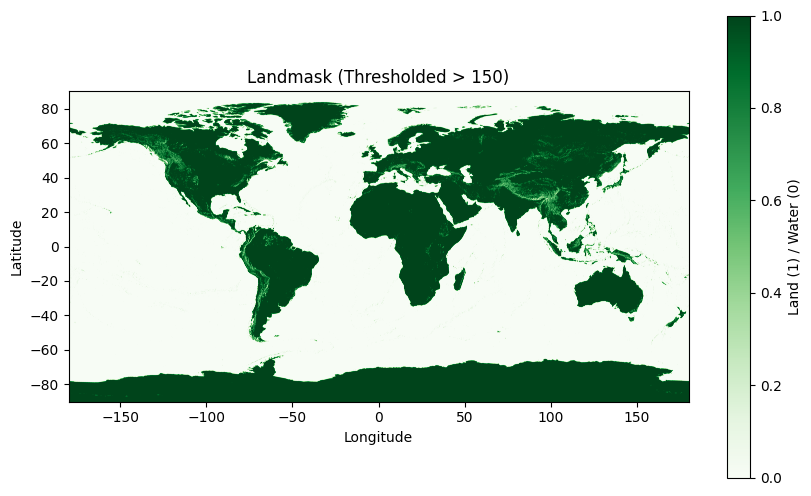

In [4]:
import rasterio
from rasterio.features import dataset_features

# Download manually (one time) or via requests:
# https://www.naturalearthdata.com/downloads/50m-raster-data/50m-natural-earth-1/

# Let's assume you have: 'NE1_50M_SR.tif'
path = "NE1_50M_SR_W.tif"

with rasterio.open(path) as src:
    data = src.read(1)
    transform = src.transform

# Natural Earth “Natural Earth 1” raster encodes land/water by color intensity.
# A better dataset for clear 0/1 classification is “NE2_landmask”.
# If using NE1, threshold the brightness (values > 128 = land, else water):
landmask = (data > 150).astype(int)

# Build coordinate arrays
nlat, nlon = landmask.shape
lons = np.linspace(-180, 180, nlon, endpoint=False)
lats = np.linspace(90, -90, nlat, endpoint=False)

# Define 30° bins
lon_bins = np.arange(-180, 181, 30)
lat_bins = np.arange(-90, 91, 30)

# Compute fraction land in each 30°×30° cell
frac_land = np.zeros((len(lat_bins)-1, len(lon_bins)-1))

for i in range(len(lat_bins)-1):
    for j in range(len(lon_bins)-1):
        lat_mask = (lats <= lat_bins[i+1]) & (lats > lat_bins[i])
        lon_mask = (lons >= lon_bins[j]) & (lons < lon_bins[j+1])
        sub = landmask[np.ix_(lat_mask, lon_mask)]
        frac_land[i,j] = sub.mean()  # fraction land in cell

frac_water = 1 - frac_land

plt.figure(figsize=(10, 6))
plt.imshow(landmask, cmap='Greens', extent=[-180, 180, -90, 90])
plt.title("Landmask (Thresholded > 150)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Land (1) / Water (0)")
plt.show()

In [5]:
# ============================================================================
# INITIALIZATION (requires land/ocean/ice fraction data)
# ============================================================================
arctic_ice = 0.367
antarctic_ice = 0.7019

# Placeholder - replace with your actual land/ocean fractions from rasterio
land_fractions = np.random.rand(12, 6) * 0.5
ocean_fractions = 1 - land_fractions

land_fractions[:, 0] *= (1 - antarctic_ice)
land_fractions[:, -1] *= (1 - arctic_ice)
ocean_fractions[:, 0] *= (1 - antarctic_ice)
ocean_fractions[:, -1] *= (1 - arctic_ice)

ice_fractions = np.zeros_like(land_fractions)
ice_fractions[:, 0] = antarctic_ice
ice_fractions[:, -1] = arctic_ice

# Setup arrays
frac_arr_init = np.vstack([np.ndarray.flatten(land_fractions),
                          np.ndarray.flatten(ocean_fractions),
                          np.ndarray.flatten(ice_fractions)])
density_arr = np.array([density_land, density_water, density_ice])
spec_heat_arr = np.array([spec_heat_land, spec_heat_water, spec_heat_ice])
depth_arr = np.array([depth_land, depth_ocean, depth_ice])
albedo_arr = np.array([albedo_surface, albedo_ocean, albedo_ice])

avg_albedos_init = np.array([average_fcn(frac_arr_init[:, i], compute_albedo, albedo_arr) 
                             for i in range(frac_arr_init.shape[1])]).reshape((12, 6))
pcZ_vals = np.array([average_fcn(frac_arr_init[:, i], compute_pcZ, density_arr, spec_heat_arr, depth_arr) 
                     for i in range(frac_arr_init.shape[1])]).reshape((12, 6))

print("Energy Balance Model with Volcanic Forcing initialized!")
print(f"Eruption configured at: lat={ERUPTIONS[0]['lat']}, lon={ERUPTIONS[0]['lon']}")
print(f"Starting at day {ERUPTIONS[0]['t0_days']} with amplitude {ERUPTIONS[0]['amplitude']}")

Energy Balance Model with Volcanic Forcing initialized!
Eruption configured at: lat=48.7767, lon=-121.8144
Starting at day 500.0 with amplitude 0.5


Starting simulation...
Step 100/3285, Day 33.3, Mean phi: 1.000
Step 200/3285, Day 66.7, Mean phi: 1.000
Step 300/3285, Day 100.0, Mean phi: 1.000
Step 400/3285, Day 133.3, Mean phi: 1.000
Step 500/3285, Day 166.7, Mean phi: 1.000
Step 600/3285, Day 200.0, Mean phi: 1.000
Step 700/3285, Day 233.3, Mean phi: 1.000
Step 800/3285, Day 266.7, Mean phi: 1.000
Step 900/3285, Day 300.0, Mean phi: 1.000
Step 1000/3285, Day 333.3, Mean phi: 1.000
Step 1100/3285, Day 366.7, Mean phi: 1.000
Step 1200/3285, Day 400.0, Mean phi: 1.000
Step 1300/3285, Day 433.3, Mean phi: 1.000
Step 1400/3285, Day 466.7, Mean phi: 1.000
Step 1500/3285, Day 500.0, Mean phi: 1.000
Step 1600/3285, Day 533.3, Mean phi: 0.961
Step 1700/3285, Day 566.7, Mean phi: 0.904
Step 1800/3285, Day 600.0, Mean phi: 0.856
Step 1900/3285, Day 633.3, Mean phi: 0.823
Step 2000/3285, Day 666.7, Mean phi: 0.803
Step 2100/3285, Day 700.0, Mean phi: 0.793
Step 2200/3285, Day 733.3, Mean phi: 0.789
Step 2300/3285, Day 766.7, Mean phi: 0.789

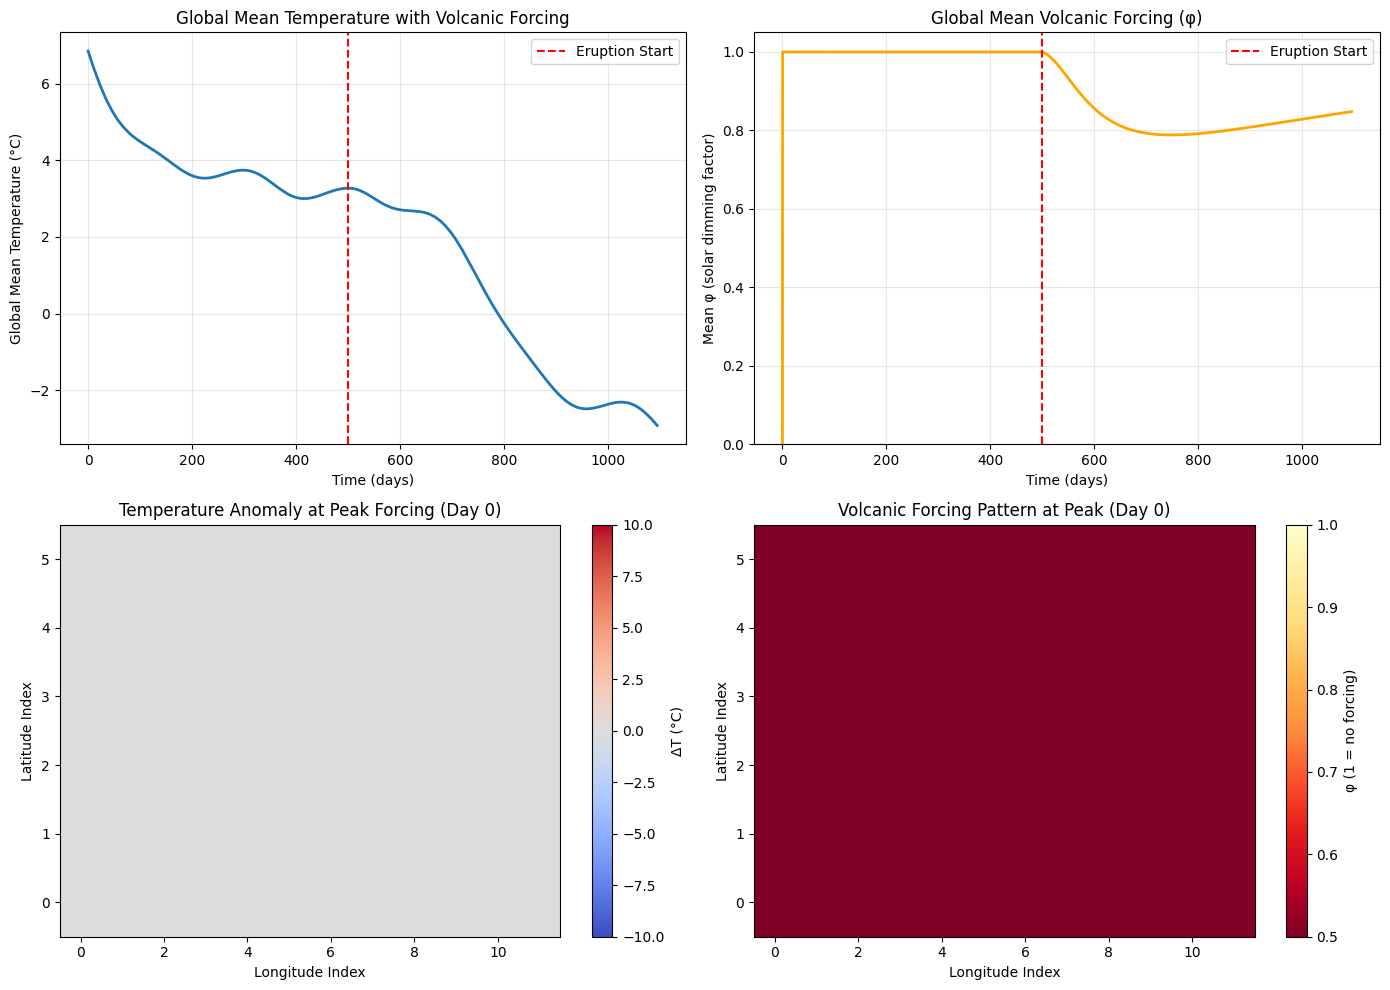


=== SIMULATION SUMMARY ===
Initial global mean temperature: 6.85°C
Final global mean temperature: -2.92°C
Maximum cooling: -9.77°C
Minimum phi (max dimming): 0.000


In [6]:
# ============================================================================
# RUN SIMULATION WITH VOLCANIC FORCING
# ============================================================================
# (Run this after the main initialization code)

temp = np.ones((12, 6)) * 280  # initial guess

# Set simulation times
dt = 3600 * 8  # time step (seconds)
years_to_run = 3
time_per_year = 365 * 24 * 3600

# Update resolutions
nsteps = int(years_to_run * (time_per_year / dt))
change_per_deg_per_year = 0.05
change_per_deg = change_per_deg_per_year * (dt / time_per_year)

# Store results over time
nlon, nlat = temp.shape
temps = np.zeros((nsteps, nlon, nlat))
temps[0] = temp

ice_fractions_over_time = np.zeros((nsteps, nlon, nlat))
ice_fractions_over_time[0] = ice_fractions

ocean_fractions_over_time = np.zeros((nsteps, nlon, nlat))
ocean_fractions_over_time[0] = ocean_fractions

land_fractions_over_time = np.zeros((nsteps, nlon, nlat))
land_fractions_over_time[0] = land_fractions

phi_over_time = np.zeros((nsteps, nlon, nlat))  # Track volcanic forcing

frac_arr = frac_arr_init
avg_albedos = avg_albedos_init
total_time = 0

print("Starting simulation...")
for t in range(1, nsteps):
    # Note: compute_dT now returns 4 values instead of 3
    temp_change, frac_arr, avg_albedos, phi = compute_dT(
        temps[t-1], total_time, frac_arr, land_fractions, 
        avg_albedos, change_per_deg=change_per_deg
    )
    temps[t, :, :] = temps[t-1] + temp_change * dt
    
    # Store fraction data
    ice_fracs = frac_arr[-1].reshape(temp_change.shape)
    ocean_fracs = frac_arr[1].reshape(temp_change.shape)
    land_fracs = frac_arr[0].reshape(temp_change.shape)
    ice_fractions_over_time[t, :, :] = ice_fracs
    ocean_fractions_over_time[t, :, :] = ocean_fracs
    land_fractions_over_time[t, :, :] = land_fracs
    phi_over_time[t, :, :] = phi
    
    total_time += dt
    
    if t % 100 == 0:
        days = total_time / (24 * 3600)
        print(f"Step {t}/{nsteps}, Day {days:.1f}, Mean phi: {phi.mean():.3f}")

# Convert to Celsius
temps -= 273.15

print("Simulation complete!")

# ============================================================================
# VISUALIZATION: Compare base case vs volcanic forcing
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Global mean temperature over time
time_axis = np.arange(nsteps) * dt / (24 * 3600)  # Convert to days
axes[0, 0].plot(time_axis, temps.mean(axis=(1, 2)), linewidth=2)
axes[0, 0].axvline(ERUPTIONS[0]['t0_days'], color='r', linestyle='--', label='Eruption Start')
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Global Mean Temperature (°C)')
axes[0, 0].set_title('Global Mean Temperature with Volcanic Forcing')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Volcanic forcing field over time (global mean)
axes[0, 1].plot(time_axis, phi_over_time.mean(axis=(1, 2)), linewidth=2, color='orange')
axes[0, 1].axvline(ERUPTIONS[0]['t0_days'], color='r', linestyle='--', label='Eruption Start')
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Mean φ (solar dimming factor)')
axes[0, 1].set_title('Global Mean Volcanic Forcing (φ)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1.05])

# Plot 3: Temperature anomaly map at peak forcing
peak_idx = np.argmin(phi_over_time.mean(axis=(1, 2)))
temp_anomaly = temps[peak_idx] - temps[0]
im3 = axes[1, 0].imshow(temp_anomaly.T, cmap='coolwarm', aspect='auto', 
                         origin='lower', vmin=-10, vmax=10)
axes[1, 0].set_xlabel('Longitude Index')
axes[1, 0].set_ylabel('Latitude Index')
axes[1, 0].set_title(f'Temperature Anomaly at Peak Forcing (Day {time_axis[peak_idx]:.0f})')
plt.colorbar(im3, ax=axes[1, 0], label='ΔT (°C)')

# Plot 4: Volcanic forcing spatial pattern at peak
im4 = axes[1, 1].imshow(phi_over_time[peak_idx].T, cmap='YlOrRd_r', aspect='auto', 
                         origin='lower', vmin=0.5, vmax=1.0)
axes[1, 1].set_xlabel('Longitude Index')
axes[1, 1].set_ylabel('Latitude Index')
axes[1, 1].set_title(f'Volcanic Forcing Pattern at Peak (Day {time_axis[peak_idx]:.0f})')
plt.colorbar(im4, ax=axes[1, 1], label='φ (1 = no forcing)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SIMULATION SUMMARY ===")
print(f"Initial global mean temperature: {temps[0].mean():.2f}°C")
print(f"Final global mean temperature: {temps[-1].mean():.2f}°C")
print(f"Maximum cooling: {(temps.mean(axis=(1,2)) - temps[0].mean()).min():.2f}°C")
print(f"Minimum phi (max dimming): {phi_over_time.mean(axis=(1,2)).min():.3f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ipywidgets import interact, FloatSlider, fixed

def create_projection_visual(timestep, temps, vmin, vmax):
    """
    Display global temperature map for a given timestep with slider
    temps: 3D array (nsteps, n_lon, n_lat)
    """
    nsteps, nlon, nlat = temps.shape

    lon_edges = np.arange(-180, 181, 30)
    lat_edges = np.arange(-90, 91, 30)

    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Draw temperature field for selected timestep
    mesh = ax.pcolormesh(
        lon_edges, lat_edges, temps[int(timestep)].T,
        cmap='coolwarm', shading='auto', alpha=0.9,vmin=vmin,vmax=vmax
    )

    # Add outlines and grid
    ax.coastlines(color='black', linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.7, edgecolor='black')
    ax.gridlines(draw_labels=True)

    plt.colorbar(mesh, ax=ax, label="Temperature (°C)")
    mesh.set_clim(vmin, vmax)
    ax.set_title(r'30$\degree$x30$\degree$ Temperature Grid — Step ' + str(int(timestep)))

    plt.show()

interact(
    create_projection_visual,
    timestep=FloatSlider(min=0, max=temps.shape[0]-1, step=1, value=0),
    temps=fixed(temps),
    vmin=fixed(np.nanmin(temps)),
    vmax=fixed(np.nanmax(temps))
)

interactive(children=(FloatSlider(value=0.0, description='timestep', max=3284.0, step=1.0), Output()), _dom_cl…

<function __main__.create_projection_visual(timestep, temps, vmin, vmax)>